# Vegetable Handcrafted Feature Visualizer
Upload any vegetable image and see all 25 handcrafted features visualized graphically.

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded.')

Libraries loaded.


In [14]:
# ── Image loader ────

IMAGE_PATH = '/home/midori/Desktop/mini-project/vegetable_Dataset/FreshApple/a_f360.png' 

img_bgr = cv2.imread(IMAGE_PATH)
if img_bgr is None:
    raise FileNotFoundError(f'Could not load image: {IMAGE_PATH}')

img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_rgb  = cv2.resize(img_rgb, (224, 224))
img_hsv  = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV).astype(np.float32) / 255.0
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0
img_norm = img_rgb.astype(np.float32) / 255.0

print(f'Image loaded: {IMAGE_PATH}  →  shape {img_rgb.shape}')

Image loaded: /home/midori/Desktop/mini-project/vegetable_Dataset/FreshApple/a_f360.png  →  shape (224, 224, 3)


In [15]:
# ── Feature extraction (mirrors extract_features.py exactly) ───────────────

h, w, _ = img_rgb.shape

rgb_mean = img_norm.mean(axis=(0, 1))          # shape (3,)
rgb_std  = img_norm.std(axis=(0, 1))           # shape (3,)
hsv_mean = img_hsv.mean(axis=(0, 1))           # shape (3,)
hsv_std  = img_hsv.std(axis=(0, 1))            # shape (3,)
gray_mean = float(img_gray.mean())
gray_std  = float(img_gray.std())

edges       = cv2.Canny((img_gray * 255).astype('uint8'), 100, 200)
edge_density = float((edges > 0).sum()) / (h * w)

lap         = cv2.Laplacian((img_gray * 255).astype('uint8'), cv2.CV_64F)
lap_var     = float(lap.var())

hist_raw = cv2.calcHist([(img_gray * 255).astype('uint8')], [0], None, [8], [0, 256]).flatten()
lum_hist = (hist_raw / hist_raw.sum()) if hist_raw.sum() > 0 else np.zeros(8)

print('Features extracted.')
print(f'  RGB mean  : {rgb_mean}')
print(f'  RGB std   : {rgb_std}')
print(f'  HSV mean  : {hsv_mean}')
print(f'  HSV std   : {hsv_std}')
print(f'  Gray mean : {gray_mean:.4f}    Gray std : {gray_std:.4f}')
print(f'  Edge dens : {edge_density:.4f}')
print(f'  Lap var   : {lap_var:.2f}')
print(f'  Lum hist  : {np.round(lum_hist, 4)}')

Features extracted.
  RGB mean  : [0.64703876 0.7007253  0.4910361 ]
  RGB std   : [0.32720202 0.32065108 0.38371232]
  HSV mean  : [0.08405921 0.30733475 0.7009125 ]
  HSV std   : [0.07930478 0.30539578 0.32050627]
  Gray mean : 0.6609    Gray std : 0.3240
  Edge dens : 0.0221
  Lap var   : 1130.34
  Lum hist  : [0.1378 0.     0.0025 0.0611 0.2339 0.1515 0.0738 0.3394]


In [16]:
# ── Helper: coloured value card ───
def value_card(ax, label, value, color, vmin=0, vmax=1, fmt='.3f'):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    frac = np.clip((value - vmin) / max(vmax - vmin, 1e-9), 0, 1)
    bg = mcolors.to_rgba(color, alpha=0.15 + 0.55 * frac)
    rect = FancyBboxPatch((0.04, 0.08), 0.92, 0.84,
                          boxstyle='round,pad=0.03',
                          facecolor=bg, edgecolor=color, linewidth=1.2)
    ax.add_patch(rect)
    ax.text(0.5, 0.68, label, ha='center', va='center',
            fontsize=7.5, fontweight='bold', color='#333333', wrap=True)
    ax.text(0.5, 0.32, f'{value:{fmt}}', ha='center', va='center',
            fontsize=11, fontweight='bold', color=color)

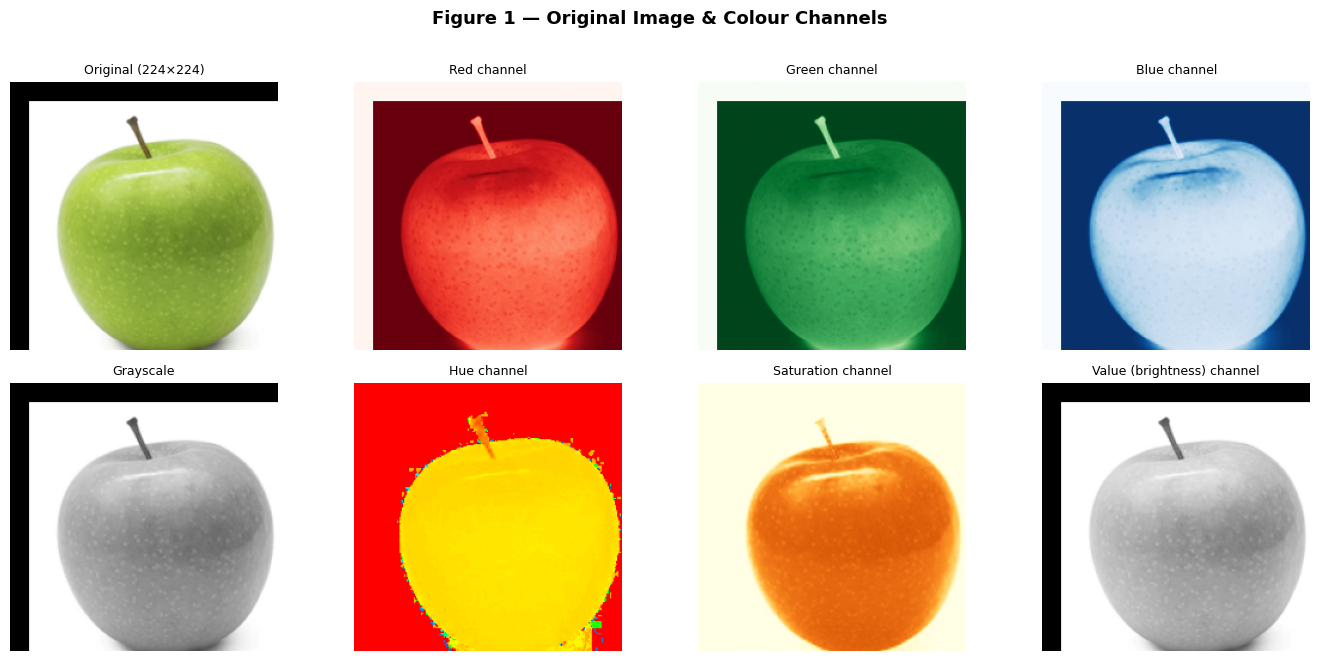

Each channel shown separately so you can see what the model measures.


In [17]:
# FIGURE 1 — Original image + colour channels

fig, axes = plt.subplots(2, 4, figsize=(14, 6.5))
fig.suptitle('Figure 1 — Original Image & Colour Channels', fontsize=13, fontweight='bold', y=1.01)

# Row 0: original + RGB channels
axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title('Original (224×224)', fontsize=9)
axes[0, 0].axis('off')

channel_labels = ['Red channel', 'Green channel', 'Blue channel']
cmaps = ['Reds', 'Greens', 'Blues']
for i in range(3):
    axes[0, i + 1].imshow(img_norm[:, :, i], cmap=cmaps[i], vmin=0, vmax=1)
    axes[0, i + 1].set_title(channel_labels[i], fontsize=9)
    axes[0, i + 1].axis('off')

# Row 1: grayscale + HSV channels
axes[1, 0].imshow(img_gray, cmap='gray', vmin=0, vmax=1)
axes[1, 0].set_title('Grayscale', fontsize=9)
axes[1, 0].axis('off')

hsv_labels = ['Hue channel', 'Saturation channel', 'Value (brightness) channel']
hsv_cmaps  = ['hsv', 'YlOrBr', 'gray']
for i in range(3):
    axes[1, i + 1].imshow(img_hsv[:, :, i], cmap=hsv_cmaps[i], vmin=0, vmax=1)
    axes[1, i + 1].set_title(hsv_labels[i], fontsize=9)
    axes[1, i + 1].axis('off')

plt.tight_layout()
plt.show()
print('Each channel shown separately so you can see what the model measures.')

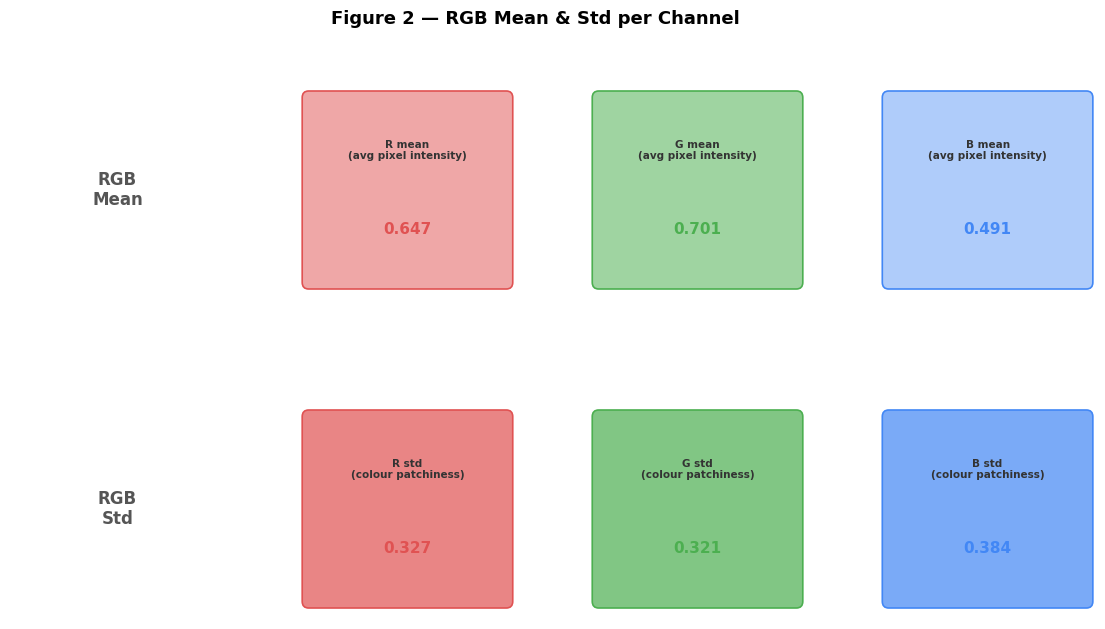

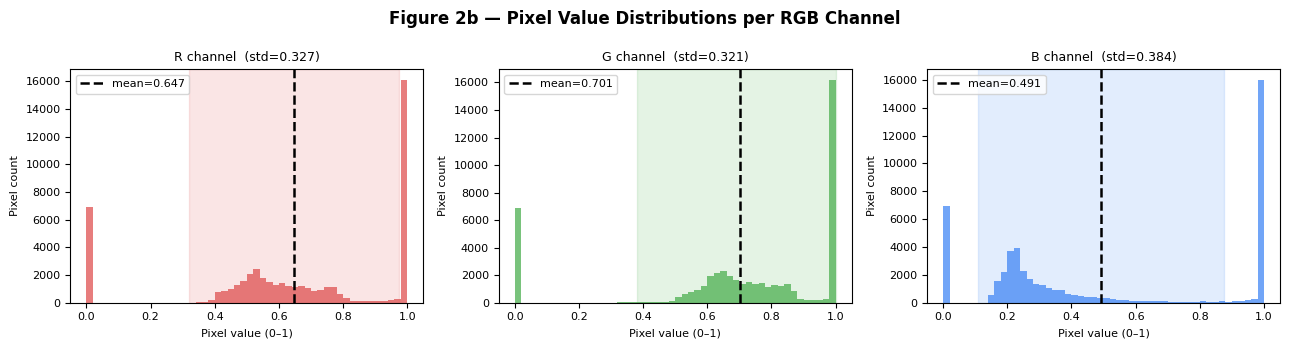

Narrow peak = uniform colour. Wide spread = patchy surface.


In [18]:
# FIGURE 2 — RGB mean & std (6 value cards + pixel distributions)

fig = plt.figure(figsize=(14, 7))
fig.suptitle('Figure 2 — RGB Mean & Std per Channel', fontsize=13, fontweight='bold')
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.35)

colors_rgb = ['#e05252', '#4caf50', '#4287f5']
ch_names   = ['R', 'G', 'B']

# Top row: mean cards
ax_title = fig.add_subplot(gs[0, 0])
ax_title.axis('off')
ax_title.text(0.5, 0.5, 'RGB\nMean', ha='center', va='center',
              fontsize=12, fontweight='bold', color='#555')
for i in range(3):
    ax = fig.add_subplot(gs[0, i + 1])
    value_card(ax, f'{ch_names[i]} mean\n(avg pixel intensity)', rgb_mean[i], colors_rgb[i])

# Bottom row: std cards
ax_title2 = fig.add_subplot(gs[1, 0])
ax_title2.axis('off')
ax_title2.text(0.5, 0.5, 'RGB\nStd', ha='center', va='center',
               fontsize=12, fontweight='bold', color='#555')
for i in range(3):
    ax = fig.add_subplot(gs[1, i + 1])
    value_card(ax, f'{ch_names[i]} std\n(colour patchiness)', rgb_std[i], colors_rgb[i], vmax=0.3)

plt.show()

# Pixel distribution histograms
fig2, axes2 = plt.subplots(1, 3, figsize=(13, 3.5))
fig2.suptitle('Figure 2b — Pixel Value Distributions per RGB Channel', fontsize=12, fontweight='bold')
for i, (ch, col) in enumerate(zip(ch_names, colors_rgb)):
    axes2[i].hist(img_norm[:, :, i].ravel(), bins=50, color=col, alpha=0.75, edgecolor='none')
    axes2[i].axvline(rgb_mean[i], color='black', lw=1.8, linestyle='--', label=f'mean={rgb_mean[i]:.3f}')
    axes2[i].set_title(f'{ch} channel  (std={rgb_std[i]:.3f})', fontsize=9)
    axes2[i].set_xlabel('Pixel value (0–1)', fontsize=8)
    axes2[i].set_ylabel('Pixel count', fontsize=8)
    axes2[i].legend(fontsize=8)
    axes2[i].tick_params(labelsize=8)
    # Annotate spread
    axes2[i].axvspan(max(0, rgb_mean[i]-rgb_std[i]),
                     min(1, rgb_mean[i]+rgb_std[i]),
                     alpha=0.15, color=col, label='±1 std')
plt.tight_layout()
plt.show()
print('Narrow peak = uniform colour. Wide spread = patchy surface.')

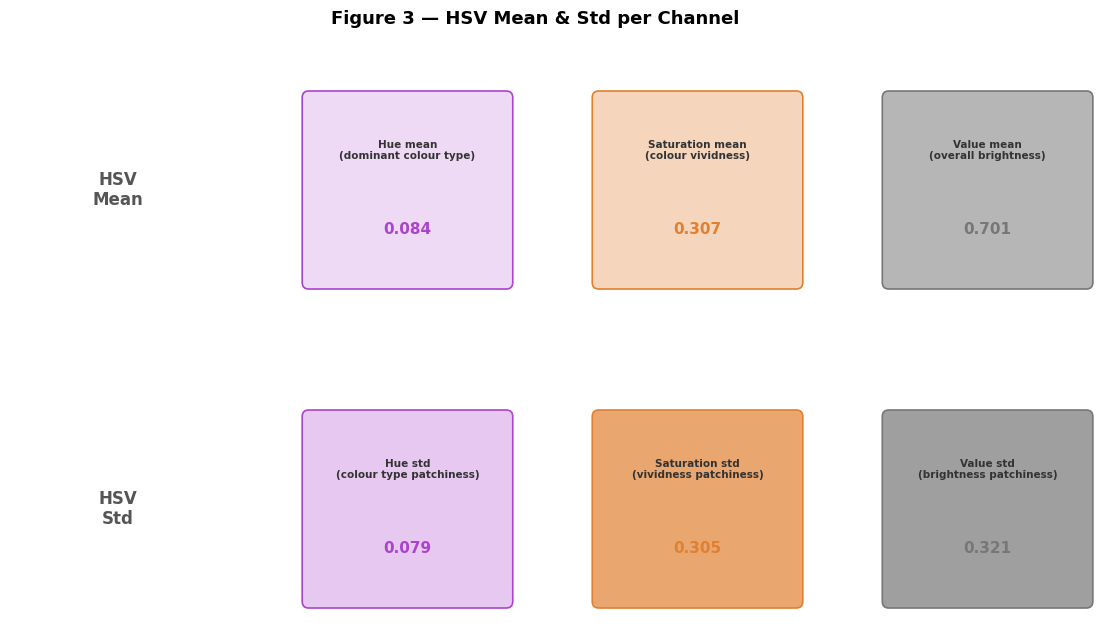

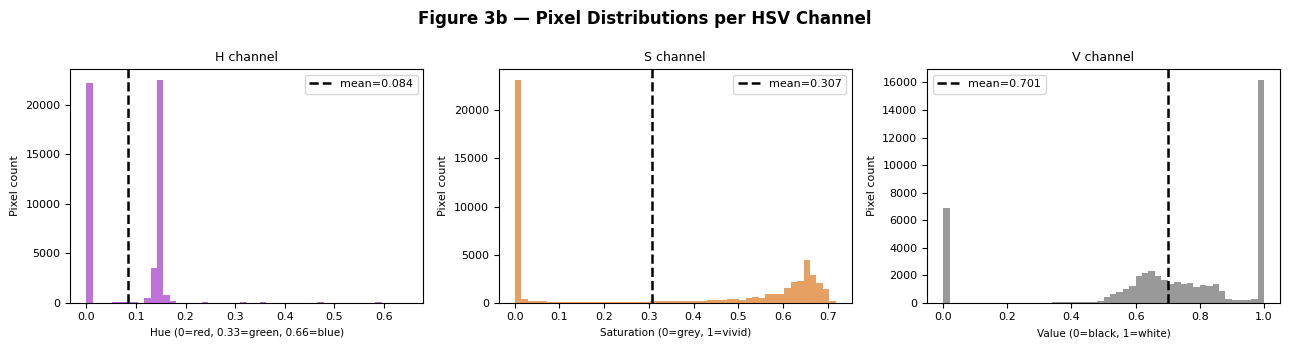

Hue std is the most diagnostic: high = mixed colours = partial rotting.


In [19]:
# FIGURE 3 — HSV mean & std (6 value cards + distributions)

fig = plt.figure(figsize=(14, 7))
fig.suptitle('Figure 3 — HSV Mean & Std per Channel', fontsize=13, fontweight='bold')
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.35)

colors_hsv  = ['#aa44cc', '#e08030', '#777777']
hsv_ch      = ['H', 'S', 'V']
hsv_labels2 = [
    'Hue mean\n(dominant colour type)',
    'Saturation mean\n(colour vividness)',
    'Value mean\n(overall brightness)'
]
hsv_std_labels = [
    'Hue std\n(colour type patchiness)',
    'Saturation std\n(vividness patchiness)',
    'Value std\n(brightness patchiness)'
]

ax_t1 = fig.add_subplot(gs[0, 0])
ax_t1.axis('off')
ax_t1.text(0.5, 0.5, 'HSV\nMean', ha='center', va='center',
           fontsize=12, fontweight='bold', color='#555')
for i in range(3):
    ax = fig.add_subplot(gs[0, i + 1])
    value_card(ax, hsv_labels2[i], hsv_mean[i], colors_hsv[i])

ax_t2 = fig.add_subplot(gs[1, 0])
ax_t2.axis('off')
ax_t2.text(0.5, 0.5, 'HSV\nStd', ha='center', va='center',
           fontsize=12, fontweight='bold', color='#555')
for i in range(3):
    ax = fig.add_subplot(gs[1, i + 1])
    value_card(ax, hsv_std_labels[i], hsv_std[i], colors_hsv[i], vmax=0.3)

plt.show()

fig2, axes2 = plt.subplots(1, 3, figsize=(13, 3.5))
fig2.suptitle('Figure 3b — Pixel Distributions per HSV Channel', fontsize=12, fontweight='bold')
for i, (ch, col, lbl) in enumerate(zip(hsv_ch, colors_hsv, ['Hue (0=red, 0.33=green, 0.66=blue)', 'Saturation (0=grey, 1=vivid)', 'Value (0=black, 1=white)'])):
    axes2[i].hist(img_hsv[:, :, i].ravel(), bins=50, color=col, alpha=0.75, edgecolor='none')
    axes2[i].axvline(hsv_mean[i], color='black', lw=1.8, linestyle='--', label=f'mean={hsv_mean[i]:.3f}')
    axes2[i].set_title(f'{ch} channel', fontsize=9)
    axes2[i].set_xlabel(lbl, fontsize=7.5)
    axes2[i].set_ylabel('Pixel count', fontsize=8)
    axes2[i].legend(fontsize=8)
    axes2[i].tick_params(labelsize=8)
plt.tight_layout()
plt.show()
print('Hue std is the most diagnostic: high = mixed colours = partial rotting.')

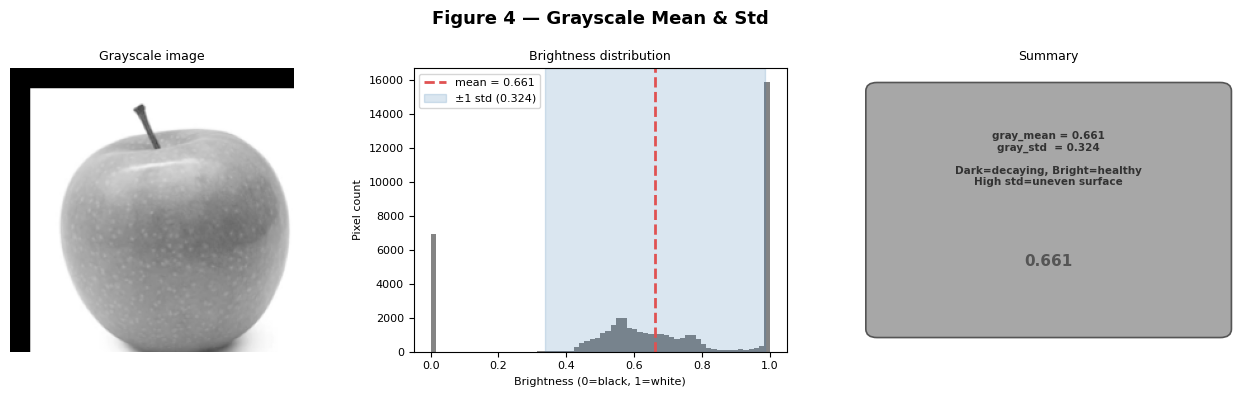

In [20]:
# FIGURE 4 — Grayscale mean & std

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Figure 4 — Grayscale Mean & Std', fontsize=13, fontweight='bold')

axes[0].imshow(img_gray, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Grayscale image', fontsize=9)
axes[0].axis('off')

axes[1].hist(img_gray.ravel(), bins=64, color='#666', alpha=0.8, edgecolor='none')
axes[1].axvline(gray_mean, color='#e05252', lw=2, linestyle='--', label=f'mean = {gray_mean:.3f}')
axes[1].axvspan(max(0, gray_mean - gray_std), min(1, gray_mean + gray_std),
                alpha=0.2, color='steelblue', label=f'±1 std ({gray_std:.3f})')
axes[1].set_title('Brightness distribution', fontsize=9)
axes[1].set_xlabel('Brightness (0=black, 1=white)', fontsize=8)
axes[1].set_ylabel('Pixel count', fontsize=8)
axes[1].legend(fontsize=8)
axes[1].tick_params(labelsize=8)

value_card(axes[2], f'gray_mean = {gray_mean:.3f}\ngray_std  = {gray_std:.3f}\n\nDark=decaying, Bright=healthy\nHigh std=uneven surface',
           gray_mean, '#555555')
axes[2].set_title('Summary', fontsize=9)

plt.tight_layout()
plt.show()

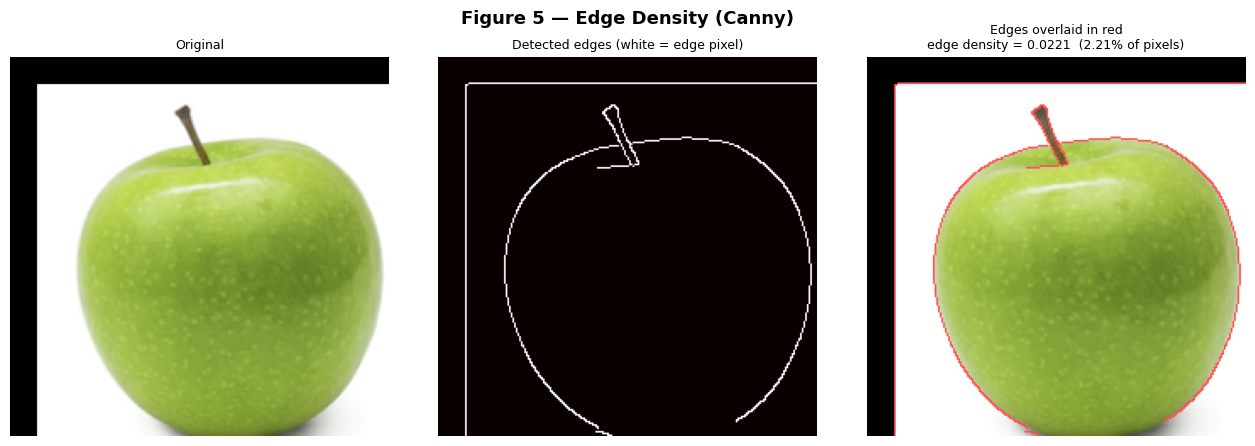

Edge density: 0.0221  — Fresh vegetables have higher density (firm, crisp structure).


In [21]:
# FIGURE 5 — Edge density (Canny)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
fig.suptitle('Figure 5 — Edge Density (Canny)', fontsize=13, fontweight='bold')

axes[0].imshow(img_rgb)
axes[0].set_title('Original', fontsize=9)
axes[0].axis('off')

axes[1].imshow(edges, cmap='hot')
axes[1].set_title('Detected edges (white = edge pixel)', fontsize=9)
axes[1].axis('off')

# Overlay: edges on original
overlay = img_rgb.copy()
overlay[edges > 0] = [255, 80, 80]
axes[2].imshow(overlay)
axes[2].set_title(f'Edges overlaid in red\nedge density = {edge_density:.4f}  ({edge_density*100:.2f}% of pixels)', fontsize=9)
axes[2].axis('off')

plt.tight_layout()
plt.show()
print(f'Edge density: {edge_density:.4f}  — Fresh vegetables have higher density (firm, crisp structure).')

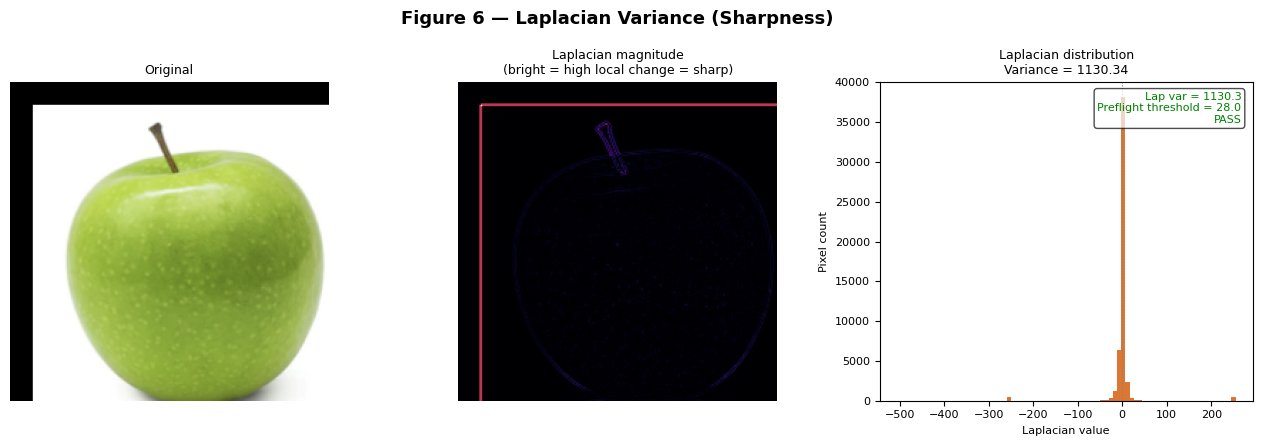

Laplacian variance: 1130.34  — Preflight threshold: 28.0  →  PASS


In [22]:
# FIGURE 6 — Laplacian variance (sharpness)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
fig.suptitle('Figure 6 — Laplacian Variance (Sharpness)', fontsize=13, fontweight='bold')

axes[0].imshow(img_rgb)
axes[0].set_title('Original', fontsize=9)
axes[0].axis('off')

lap_display = np.abs(lap)
axes[1].imshow(lap_display, cmap='inferno')
axes[1].set_title('Laplacian magnitude\n(bright = high local change = sharp)', fontsize=9)
axes[1].axis('off')

axes[2].hist(lap.ravel(), bins=80, color='#d45500', alpha=0.8, edgecolor='none')
axes[2].set_title(f'Laplacian distribution\nVariance = {lap_var:.2f}', fontsize=9)
axes[2].set_xlabel('Laplacian value', fontsize=8)
axes[2].set_ylabel('Pixel count', fontsize=8)
axes[2].tick_params(labelsize=8)

# Add preflight threshold line
axes[2].axvline(0, color='gray', lw=0.8, linestyle=':')
threshold_note = f'Lap var = {lap_var:.1f}\nPreflight threshold = 28.0\n{"PASS" if lap_var >= 28 else "FAIL (too blurry)"}'
axes[2].text(0.97, 0.97, threshold_note, transform=axes[2].transAxes,
             ha='right', va='top', fontsize=8,
             color='green' if lap_var >= 28 else 'red',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()
print(f'Laplacian variance: {lap_var:.2f}  — Preflight threshold: 28.0  →  {"PASS" if lap_var >= 28 else "FAIL"}')

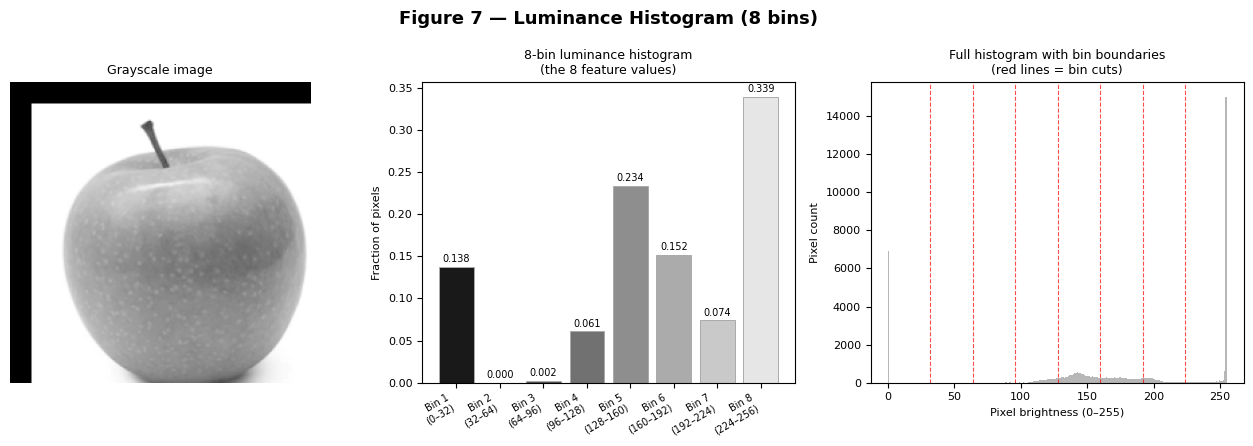

These 8 bin fractions are the actual feature values fed into the SVM.
Values: [0.1378 0.     0.0025 0.0611 0.2339 0.1515 0.0738 0.3394]


In [23]:
# FIGURE 7 — Luminance histogram (8 bins)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
fig.suptitle('Figure 7 — Luminance Histogram (8 bins)', fontsize=13, fontweight='bold')

axes[0].imshow(img_gray, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Grayscale image', fontsize=9)
axes[0].axis('off')

bin_edges   = np.linspace(0, 256, 9)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_labels  = [f'{int(b)}' for b in bin_edges[:-1]]
bar_colors  = plt.cm.gray(np.linspace(0.1, 0.9, 8))

bars = axes[1].bar(range(8), lum_hist, color=bar_colors, edgecolor='#aaa', linewidth=0.7)
axes[1].set_xticks(range(8))
axes[1].set_xticklabels([f'Bin {i+1}\n({bin_labels[i]}–{int(bin_edges[i+1])})' for i in range(8)],
                         fontsize=7, rotation=30, ha='right')
axes[1].set_ylabel('Fraction of pixels', fontsize=8)
axes[1].set_title('8-bin luminance histogram\n(the 8 feature values)', fontsize=9)
axes[1].tick_params(axis='y', labelsize=8)
for bar, val in zip(bars, lum_hist):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=7)

# Full-resolution histogram for context
axes[2].hist(img_gray.ravel() * 255, bins=256, color='#888', alpha=0.6, edgecolor='none', label='Full res')
for edge in bin_edges[1:-1]:
    axes[2].axvline(edge, color='red', lw=0.8, linestyle='--', alpha=0.7)
axes[2].set_title('Full histogram with bin boundaries\n(red lines = bin cuts)', fontsize=9)
axes[2].set_xlabel('Pixel brightness (0–255)', fontsize=8)
axes[2].set_ylabel('Pixel count', fontsize=8)
axes[2].tick_params(labelsize=8)

plt.tight_layout()
plt.show()
print('These 8 bin fractions are the actual feature values fed into the SVM.')
print(f'Values: {np.round(lum_hist, 4)}')